# Strategy Backtest
Runs the intraday statistical-arbitrage pairs-trading strategy.

In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

from utils.config import Config
from strategy.backtester import run_backtest, save_results

## 1. Configure and Run
cointegration param tune: 2017-2018
in-sample backtest: 2019-2022
OOS backtest: 2023-2025

In [ ]:
# ── Parameters ───────────────────────────────────────────────────────────────
# Other levers to explore (in rough priority order):
#   z_entry:              2.5 → more trades, slightly lower quality
#                         3.5 → fewer but higher-quality entries
#   zscore_window_days:   2   → faster signal (more reactive to intraday moves)
#                         10  → smoother but slower
#   rolling_window_days:  126 → more stable cointegration (vs current 84)
#   min_bars_remaining:   4   → allow entries up to 1h before close (vs 2h now)

cfg = Config()

# Backtest period & execution
cfg.portfolio.start_date            = "2017-01-01"
cfg.portfolio.end_date              = "2026-02-28"
cfg.portfolio.timeframe             = "15min"
cfg.portfolio.min_bars_remaining    = 8
cfg.portfolio.execution_lag_minutes = 2
cfg.portfolio.execution_price_field = "close"

# Portfolio sizing & costs
cfg.portfolio.capital               = 1_000_000.0
cfg.portfolio.max_pairs             = 20
cfg.portfolio.transaction_cost_bps  = 5.0
cfg.portfolio.use_pvalue_weights    = False 

# Cointegration formation
cfg.cointegration.rolling_window_days  = 42
cfg.cointegration.require_split_window = False
cfg.cointegration.min_half_life = 2
cfg.cointegration.max_half_life = 24

# Signal parameters
cfg.signal.zscore_window_days  = 5
cfg.signal.z_entry             = 3
cfg.signal.z_exit              = 2.25   # partial reversion (1σ retrace from entry)
cfg.signal.z_stop              = 6
cfg.signal.max_holding_minutes = 9999   # TODO: play around with this
cfg.signal.fixed_exit_norm     = True

In [3]:
print("Running backtest …")
trades_df, daily_pnl_df = run_backtest(config=cfg)
print(f"\nDone. {len(trades_df)} trades over {len(daily_pnl_df)} trading days.")

Running backtest …
Not enough tickers with data for cointegration analysis.


Testing cointegration 2017-01-03: 100%|██████████| 2487/2487 [00:00<00:00, 122361.95it/s]


No cointegrated pairs found with current thresholds.


Testing cointegration 2017-01-04: 100%|██████████| 2487/2487 [00:00<00:00, 120653.67it/s]


No cointegrated pairs found with current thresholds.


Testing cointegration 2026-02-26: 100%|██████████| 2610/2610 [00:00<00:00, 7380.87it/s]



Done. 32161 trades over 2301 trading days.


In [4]:
# Save to parquet (also loads pre-computed if you skip cell-3)

def _pval(v):
    """Stringify a param value for use in a filename (strip trailing .0, None → 'none')."""
    if v is None:
        return "none"
    if isinstance(v, float) and v == int(v):
        return str(int(v))
    return str(v)

param_str = (
    f"tf{cfg.portfolio.timeframe}"
    f"_zw{cfg.signal.zscore_window_days}"
    f"_wd{cfg.cointegration.rolling_window_days}"
    f"_ze{_pval(cfg.signal.z_entry)}"
    f"_zx{_pval(cfg.signal.z_exit)}"
    f"_zs{_pval(cfg.signal.z_stop)}"
    f"_lhl{cfg.cointegration.min_half_life}"
    f"_hhl{cfg.cointegration.max_half_life}"
    f"_mp{cfg.portfolio.max_pairs}"
    f"_mh{cfg.signal.max_holding_minutes}"
    f"_mbr{cfg.portfolio.min_bars_remaining}"
    f"_cb{_pval(cfg.portfolio.transaction_cost_bps)}"
    f"_pv{_pval(cfg.portfolio.use_pvalue_weights)}"
    f"_{cfg.portfolio.start_date}_{cfg.portfolio.end_date}"
)
save_results(trades_df, daily_pnl_df, label=param_str)

Trades saved to:     /Users/erevtsov/dev/stat-arb/results/trades/trades_tf15min_zw5_wd42_ze3_zx2.25_zs6_lhl2_hhl24_mp20_mh9999_mbr8_cb5_pvFalse_2017-01-01_2026-02-28.parquet
Daily PnL saved to:  /Users/erevtsov/dev/stat-arb/results/portfolio/daily_pnl_tf15min_zw5_wd42_ze3_zx2.25_zs6_lhl2_hhl24_mp20_mh9999_mbr8_cb5_pvFalse_2017-01-01_2026-02-28.parquet


In [5]:
### Alternative: load pre-computed results (skip cell-3 re-run)
# trades_df    = pl.read_parquet("../results/trades/trades_15min.parquet")
# daily_pnl_df = pl.read_parquet("../results/portfolio/daily_pnl_15min.parquet")

## 2. Portfolio Summary

In [6]:
capital = cfg.portfolio.capital
final_value = daily_pnl_df["portfolio_value"][-1]
total_net_pnl = daily_pnl_df["net_pnl"].sum()
total_gross_pnl = daily_pnl_df["gross_pnl"].sum()

# Daily returns for Sharpe
daily_returns = (daily_pnl_df["net_pnl"] / daily_pnl_df["portfolio_value"].shift(1)).drop_nulls()
sharpe = float(daily_returns.mean() / daily_returns.std() * np.sqrt(252)) if daily_returns.std() > 0 else float("nan")

# Max drawdown
pv = daily_pnl_df["portfolio_value"].to_numpy()
running_max = np.maximum.accumulate(pv)
drawdowns = (pv - running_max) / running_max
max_drawdown = float(drawdowns.min())

# Trade-level
n_trades = len(trades_df)
if n_trades > 0:
    win_mask = trades_df["net_pnl"] > 0
    win_rate = win_mask.mean()
    avg_net_pnl = trades_df["net_pnl"].mean()
    avg_gross_pnl = trades_df["gross_pnl"].mean()
    avg_cost = trades_df["transaction_cost"].mean()
    avg_hold = (
        (trades_df["exit_time"] - trades_df["entry_time"])
        .dt.total_minutes()
        .mean()
    )
    reasons = trades_df["exit_reason"].value_counts().sort("exit_reason")
    def _pct(reason):
        row = reasons.filter(pl.col("exit_reason") == reason)
        return float(row["count"][0]) / n_trades if len(row) else 0.0
    pct_z_exit   = _pct("z_exit")
    pct_z_stop   = _pct("z_stop")
    pct_max_hold = _pct("max_hold")
    pct_eod      = _pct("eod")
else:
    win_rate = avg_net_pnl = avg_gross_pnl = avg_cost = avg_hold = float("nan")
    pct_z_exit = pct_z_stop = pct_max_hold = pct_eod = float("nan")

print("=" * 55)
print("PORTFOLIO SUMMARY")
print("=" * 55)
print(f"  Period             : {cfg.portfolio.start_date} → {cfg.portfolio.end_date}")
print(f"  Starting capital   : ${capital:>12,.2f}")
print(f"  Final value        : ${final_value:>12,.2f}")
print(f"  Total net P&L      : ${total_net_pnl:>+12,.2f}")
print(f"  Total return       : {(final_value / capital - 1):>+11.2%}")
print(f"  Annualised Sharpe  : {sharpe:>12.3f}")
print(f"  Max drawdown       : {max_drawdown:>+11.2%}")
print()
print("TRADE SUMMARY")
print("=" * 55)
print(f"  Total trades       : {n_trades:>12,}")
print(f"  Win rate           : {win_rate:>12.1%}")
print(f"  Avg gross P&L      : ${avg_gross_pnl:>+12.2f}")
print(f"  Avg transaction cost: ${avg_cost:>+11.2f}")
print(f"  Avg net P&L        : ${avg_net_pnl:>+12.2f}")
print(f"  Avg hold (minutes) : {avg_hold:>12.1f}")
print()
print("EXIT REASON BREAKDOWN")
print("=" * 55)
print(f"  z_exit (reversion) : {pct_z_exit:>12.1%}")
print(f"  z_stop (stop-loss) : {pct_z_stop:>12.1%}")
print(f"  max_hold (timeout) : {pct_max_hold:>12.1%}")
print(f"  eod (final day)    : {pct_eod:>12.1%}")

PORTFOLIO SUMMARY
  Period             : 2017-01-01 → 2026-02-28
  Starting capital   : $1,000,000.00
  Final value        : $1,490,740.68
  Total net P&L      : $ +490,740.68
  Total return       :     +49.07%
  Annualised Sharpe  :        0.574
  Max drawdown       :     -55.66%

TRADE SUMMARY
  Total trades       :       32,161
  Win rate           :        58.7%
  Avg gross P&L      : $     +199.88
  Avg transaction cost: $    +184.63
  Avg net P&L        : $      +15.26
  Avg hold (minutes) :        219.1

EXIT REASON BREAKDOWN
  z_exit (reversion) :        47.3%
  z_stop (stop-loss) :         4.5%
  max_hold (timeout) :         0.0%
  eod (final day)    :        48.2%


## 3. Equity Curve

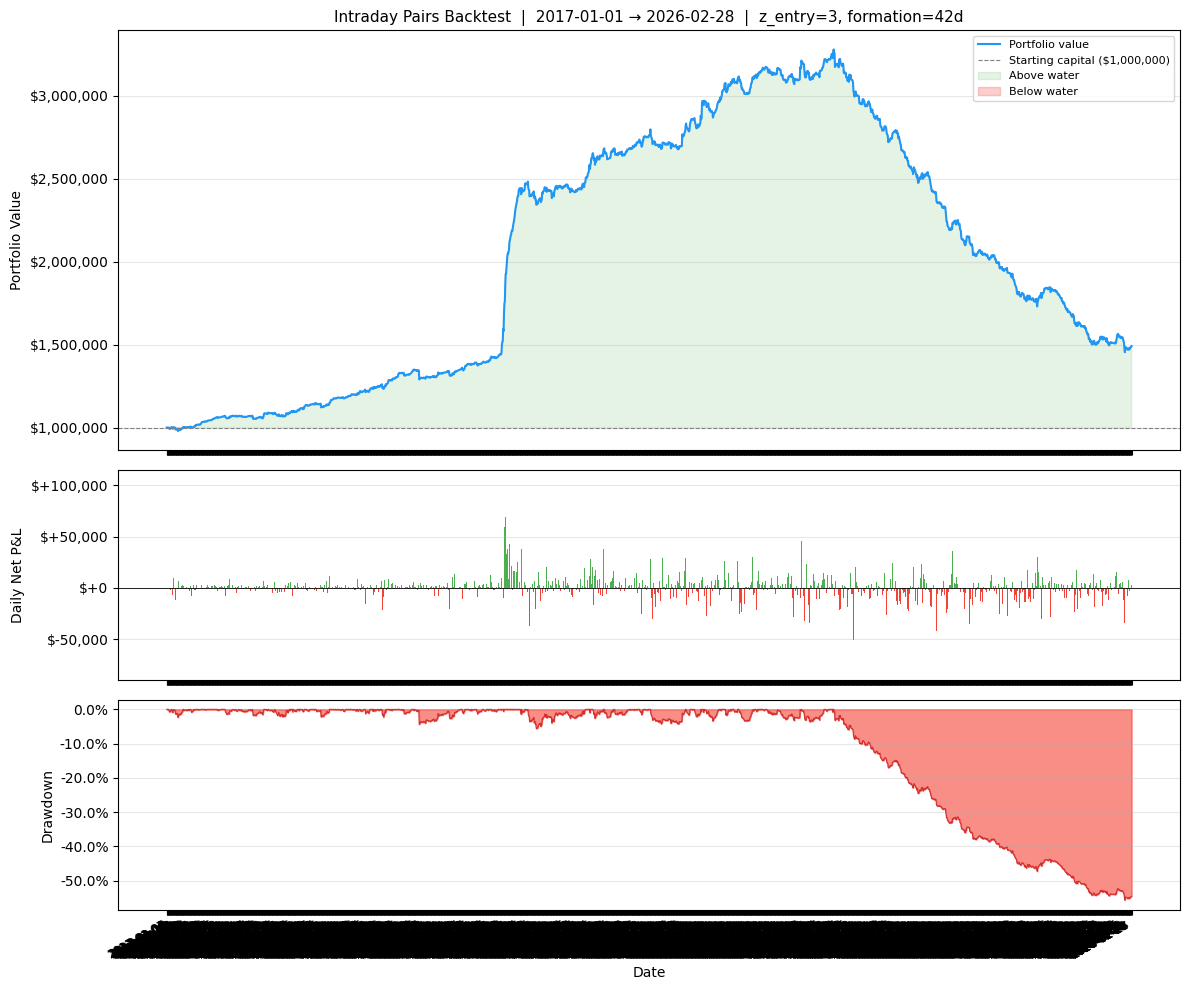

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1.5, 1.5]})

dates = daily_pnl_df["date"].to_list()
portfolio_values = daily_pnl_df["portfolio_value"].to_numpy()
net_pnls = daily_pnl_df["net_pnl"].to_numpy()
drawdowns_pct = drawdowns * 100

# ── Panel 1: Equity curve ──────────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(dates, portfolio_values, color="#2196F3", linewidth=1.5, label="Portfolio value")
ax1.axhline(capital, color="grey", linewidth=0.8, linestyle="--", label=f"Starting capital (${capital:,.0f})")
ax1.fill_between(dates, capital, portfolio_values,
                  where=(np.array(portfolio_values) >= capital),
                  alpha=0.15, color="#4CAF50", label="Above water")
ax1.fill_between(dates, capital, portfolio_values,
                  where=(np.array(portfolio_values) < capital),
                  alpha=0.25, color="#F44336", label="Below water")
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax1.set_ylabel("Portfolio Value")
ax1.set_title(
    f"Intraday Pairs Backtest  |  "
    f"{cfg.portfolio.start_date} → {cfg.portfolio.end_date}  |  "
    f"z_entry={cfg.signal.z_entry}, formation={cfg.cointegration.rolling_window_days}d",
    fontsize=11,
)
ax1.legend(fontsize=8)
ax1.grid(axis="y", alpha=0.3)

# ── Panel 2: Daily net P&L bar chart ──────────────────────────────────────
ax2 = axes[1]
colors = ["#4CAF50" if v >= 0 else "#F44336" for v in net_pnls]
ax2.bar(dates, net_pnls, color=colors, width=0.8)
ax2.axhline(0, color="black", linewidth=0.6)
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:+,.0f}"))
ax2.set_ylabel("Daily Net P&L")
ax2.grid(axis="y", alpha=0.3)

# ── Panel 3: Drawdown ─────────────────────────────────────────────────────
ax3 = axes[2]
ax3.fill_between(dates, drawdowns_pct, 0, color="#F44336", alpha=0.6)
ax3.plot(dates, drawdowns_pct, color="#D32F2F", linewidth=0.8)
ax3.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.1f}%"))
ax3.set_ylabel("Drawdown")
ax3.set_xlabel("Date")
ax3.grid(axis="y", alpha=0.3)

# rotate x-tick labels
for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)

plt.tight_layout()
plt.show()

## 4. P&L Distributions

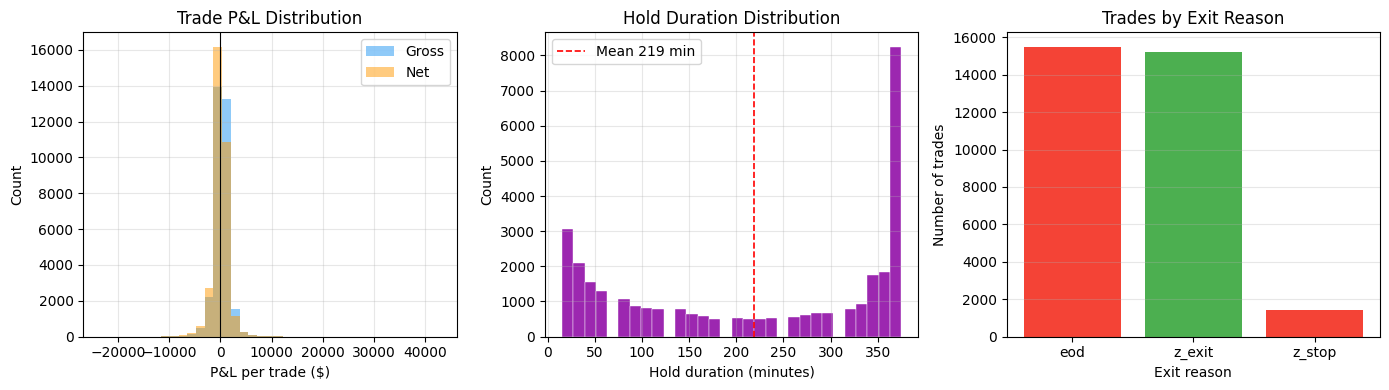

In [8]:
if len(trades_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # ── Gross vs Net P&L per trade ────────────────────────────────────────
    ax = axes[0]
    gross = trades_df["gross_pnl"].to_numpy()
    net = trades_df["net_pnl"].to_numpy()
    bins = np.linspace(min(gross.min(), net.min()), max(gross.max(), net.max()), 40)
    ax.hist(gross, bins=bins, alpha=0.5, color="#2196F3", label="Gross")
    ax.hist(net,   bins=bins, alpha=0.5, color="#FF9800", label="Net")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("P&L per trade ($)")
    ax.set_ylabel("Count")
    ax.set_title("Trade P&L Distribution")
    ax.legend()
    ax.grid(alpha=0.3)

    # ── Hold duration ─────────────────────────────────────────────────────
    ax = axes[1]
    hold_mins = (trades_df["exit_time"] - trades_df["entry_time"]).dt.total_minutes().to_numpy()
    ax.hist(hold_mins, bins=30, color="#9C27B0", edgecolor="white", linewidth=0.3)
    ax.axvline(float(np.mean(hold_mins)), color="red", linewidth=1.2,
               linestyle="--", label=f"Mean {np.mean(hold_mins):.0f} min")
    ax.set_xlabel("Hold duration (minutes)")
    ax.set_ylabel("Count")
    ax.set_title("Hold Duration Distribution")
    ax.legend()
    ax.grid(alpha=0.3)

    # ── Exit reason breakdown ─────────────────────────────────────────────
    ax = axes[2]
    reasons = trades_df.group_by("exit_reason").agg(pl.len().alias("n")).sort("exit_reason")
    ax.bar(reasons["exit_reason"].to_list(), reasons["n"].to_list(),
           color=["#F44336", "#4CAF50"])
    ax.set_xlabel("Exit reason")
    ax.set_ylabel("Number of trades")
    ax.set_title("Trades by Exit Reason")
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No trades to plot.")

## 5. Win Rate by Direction and Exit Reason

In [9]:
if len(trades_df) > 0:
    summary = (
        trades_df
        .with_columns(pl.when(pl.col("net_pnl") > 0).then(1).otherwise(0).alias("win"))
        .group_by(["direction", "exit_reason"])
        .agg(
            pl.col("win").mean().alias("win_rate"),
            pl.col("net_pnl").mean().alias("avg_net_pnl"),
            pl.col("gross_pnl").mean().alias("avg_gross_pnl"),
            pl.len().alias("n_trades"),
        )
        .sort(["direction", "exit_reason"])
    )
    print("Win rate and avg P&L by direction × exit reason:")
    print(summary.to_pandas().to_string(index=False))

    print()

    # Monthly P&L
    monthly = (
        daily_pnl_df
        .with_columns(pl.col("date").str.slice(0, 7).alias("month"))
        .group_by("month")
        .agg(
            pl.col("net_pnl").sum().alias("net_pnl"),
            pl.col("gross_pnl").sum().alias("gross_pnl"),
            pl.col("n_trades").sum().alias("n_trades"),
        )
        .sort("month")
    )
    print("Monthly P&L summary:")
    print(monthly.to_pandas().to_string(index=False))

Win rate and avg P&L by direction × exit reason:
 direction exit_reason  win_rate  avg_net_pnl  avg_gross_pnl  n_trades
        -1         eod  0.257968  -654.898978    -466.383296      8063
        -1      z_exit  0.944788   773.361597     952.316784      7770
        -1      z_stop  0.196402  -735.594937    -557.034498       667
         1         eod  0.279273  -684.362277    -491.402390      7430
         1      z_exit  0.949571   776.637109     956.937803      7456
         1      z_stop  0.238710  -584.491878    -416.576009       775

Monthly P&L summary:
  month        net_pnl     gross_pnl  n_trades
2017-01   -1053.831638  23304.741373       317
2017-02   -2452.129871  23784.088077       279
2017-03    3454.116064  34661.747990       379
2017-04   18974.388174  42304.693427       284
2017-05   24847.276269  43346.422674       219
2017-06   16431.342706  35799.974524       195
2017-07   -4698.257770  19538.698741       243
2017-08   10046.689667  32145.571959       229
2017-09  

## 6. Monthly Returns Heatmap

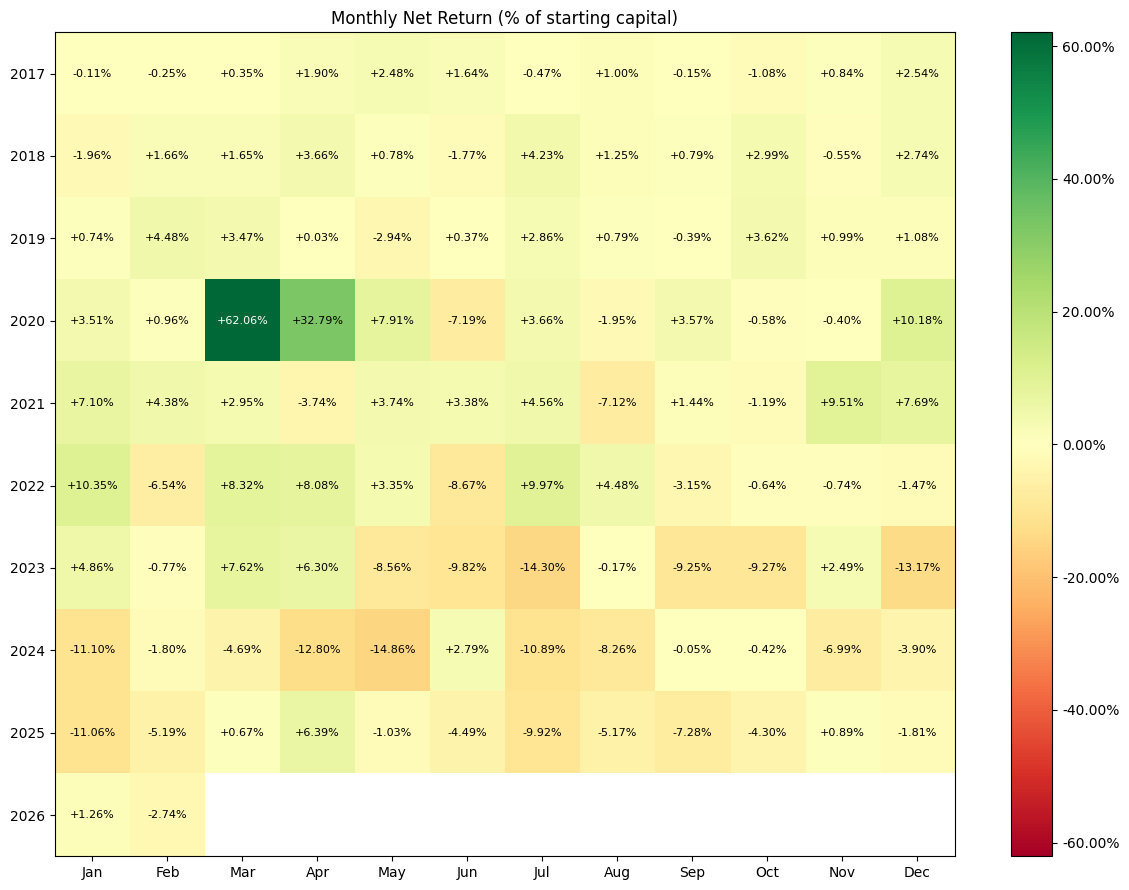

In [10]:
# Compute monthly net return (% of starting capital) for heatmap
if len(daily_pnl_df) > 0:
    monthly_ret = (
        daily_pnl_df
        .with_columns(
            pl.col("date").str.slice(0, 4).alias("year"),
            pl.col("date").str.slice(5, 2).alias("month"),
        )
        .group_by(["year", "month"])
        .agg(pl.col("net_pnl").sum().alias("net_pnl"))
        .sort(["year", "month"])
        .with_columns(
            (pl.col("net_pnl") / capital * 100).alias("return_pct")
        )
    )

    years  = sorted(monthly_ret["year"].unique().to_list())
    months = [f"{m:02d}" for m in range(1, 13)]
    month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"]

    grid = np.full((len(years), 12), np.nan)
    for row in monthly_ret.iter_rows(named=True):
        yi = years.index(row["year"])
        mi = int(row["month"]) - 1
        grid[yi, mi] = row["return_pct"]

    fig, ax = plt.subplots(figsize=(12, max(2, len(years) * 0.9)))
    vmax = np.nanmax(np.abs(grid))
    im = ax.imshow(grid, cmap="RdYlGn", vmin=-vmax, vmax=vmax, aspect="auto")

    ax.set_xticks(range(12))
    ax.set_xticklabels(month_labels)
    ax.set_yticks(range(len(years)))
    ax.set_yticklabels(years)
    ax.set_title("Monthly Net Return (% of starting capital)")
    plt.colorbar(im, ax=ax, format="%.2f%%")

    for yi in range(len(years)):
        for mi in range(12):
            val = grid[yi, mi]
            if not np.isnan(val):
                ax.text(mi, yi, f"{val:+.2f}%", ha="center", va="center", fontsize=8,
                        color="black" if abs(val) < vmax * 0.6 else "white")

    plt.tight_layout()
    plt.show()

## 7. Sample Trade Log

In [11]:
if len(trades_df) > 0:
    sample = (
        trades_df
        .sort("entry_time")
        .select([
            "entry_time", "exit_time", "ticker_a", "ticker_b",
            "direction", "gross_pnl", "transaction_cost", "net_pnl", "exit_reason",
        ])
        .head(20)
    )
    print("First 20 trades (sorted by entry time):")
    print(sample.to_pandas().to_string(index=False))
else:
    print("No trades recorded.")

First 20 trades (sorted by entry time):
         entry_time           exit_time ticker_a ticker_b  direction   gross_pnl  transaction_cost     net_pnl exit_reason
2017-01-10 09:45:00 2017-01-10 10:00:00      NEE      PSA          1   54.969182         52.409581    2.559602      z_exit
2017-01-10 09:45:00 2017-01-10 10:00:00      WMB      KMI          1 -546.494230        126.116237 -672.610467      z_stop
2017-01-10 09:45:00 2017-01-10 10:00:00      NEE      SPG          1   50.872869         51.865573   -0.992704      z_exit
2017-01-10 09:45:00 2017-01-10 10:00:00       HD     ROST         -1  233.833411         89.072380  144.761031      z_exit
2017-01-10 09:45:00 2017-01-10 10:15:00      CFG      KEY         -1  273.960863         95.563390  178.397473      z_exit
2017-01-10 09:45:00 2017-01-10 11:15:00       SO     EQIX          1   77.943746         55.711316   22.232430      z_exit
2017-01-10 09:45:00 2017-01-10 11:30:00       ES      XEL          1  103.704891         94.140378 

## 8. Simultaneous Open Positions

Is the `max_pairs` cap binding? How often is the portfolio at full capacity,
and how many slots are typically in use at any moment?

max_pairs limit : 20
Peak concurrent : 37  ← LIMIT HIT
Events at cap   : 2,178 / 64,322 (3.4% of entry/exit events)

Concurrent open positions distribution (at event timestamps):
   Count   Events       %
       0    2,338    3.6%
       1    4,706    7.3%
       2    4,750    7.4%
       3    4,735    7.4%
       4    4,683    7.3%
       5    4,592    7.1%
       6    4,412    6.9%
       7    4,150    6.5%
       8    3,881    6.0%
       9    3,560    5.5%
      10    3,172    4.9%
      11    2,901    4.5%
      12    2,671    4.2%
      13    2,400    3.7%
      14    2,086    3.2%
      15    1,783    2.8%
      16    1,544    2.4%
      17    1,353    2.1%
      18    1,233    1.9%
      19    1,194    1.9%
      20    1,123    1.7% ← CAP
      21      671    1.0% ← CAP
      22      211    0.3% ← CAP
      23       83    0.1% ← CAP
      24       36    0.1% ← CAP
      25       19    0.0% ← CAP
      26       10    0.0% ← CAP
      27        5    0.0% ← CAP
      28        3  

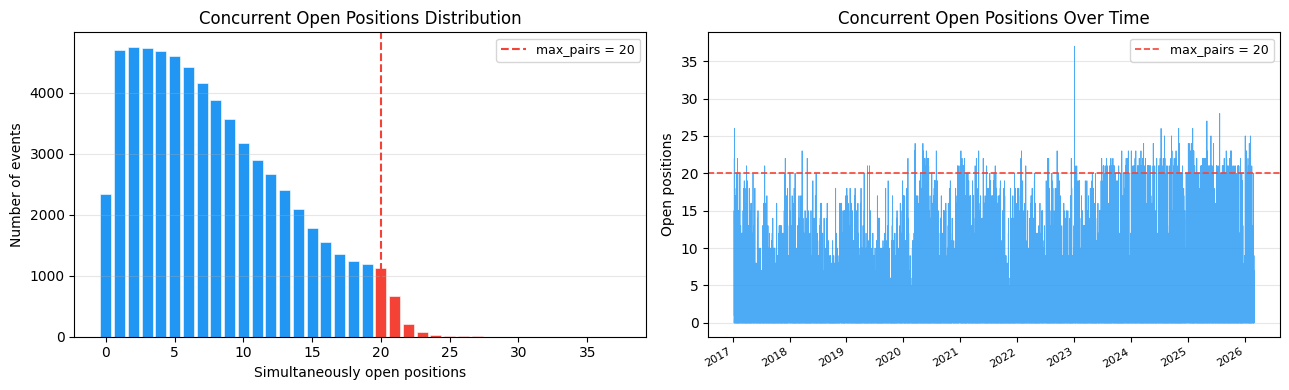

In [12]:
if len(trades_df) > 0:
    max_pairs = cfg.portfolio.max_pairs

    # Build a change-stream: +1 at entry, -1 at exit.
    # Sorting and cumsum gives concurrent open count at every event.
    entries = trades_df.select(pl.col("entry_time").alias("ts"), pl.lit(1).alias("delta"))
    exits   = trades_df.select(pl.col("exit_time").alias("ts"),  pl.lit(-1).alias("delta"))
    events  = pl.concat([entries, exits]).sort("ts")
    events  = events.with_columns(pl.col("delta").cum_sum().alias("open_count"))

    concurrent = events["open_count"].to_numpy()
    peak       = int(concurrent.max())
    at_cap     = int((concurrent >= max_pairs).sum())
    total_events = len(events)

    print(f"max_pairs limit : {max_pairs}")
    print(f"Peak concurrent : {peak}  {'← LIMIT HIT' if peak >= max_pairs else '← below limit'}")
    print(f"Events at cap   : {at_cap:,} / {total_events:,} ({at_cap/total_events:.1%} of entry/exit events)")
    print()

    # Distribution of concurrent open count
    from collections import Counter
    dist = Counter(concurrent.tolist())
    print("Concurrent open positions distribution (at event timestamps):")
    print(f"  {'Count':>6}  {'Events':>7}  {'%':>6}")
    for k in sorted(dist):
        marker = " ← CAP" if k >= max_pairs else ""
        print(f"  {k:>6}  {dist[k]:>7,}  {dist[k]/total_events:>6.1%}{marker}")

    # ── Plot ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Left: histogram of concurrent count
    ax = axes[0]
    vals = sorted(dist.keys())
    counts = [dist[v] for v in vals]
    bar_colors = ["#F44336" if v >= max_pairs else "#2196F3" for v in vals]
    ax.bar(vals, counts, color=bar_colors, edgecolor="white", linewidth=0.4)
    ax.axvline(max_pairs, color="#F44336", linewidth=1.5, linestyle="--",
               label=f"max_pairs = {max_pairs}")
    ax.set_xlabel("Simultaneously open positions")
    ax.set_ylabel("Number of events")
    ax.set_title("Concurrent Open Positions Distribution")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

    # Right: time-series of concurrent count (sampled at each event)
    ax = axes[1]
    ts_list = events["ts"].to_list()
    ax.plot(ts_list, concurrent, color="#2196F3", linewidth=0.6, alpha=0.8)
    ax.axhline(max_pairs, color="#F44336", linewidth=1.2, linestyle="--",
               label=f"max_pairs = {max_pairs}")
    ax.set_ylabel("Open positions")
    ax.set_title("Concurrent Open Positions Over Time")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print("No trades to analyse.")

## 9. Hold Duration vs Profitability

Two questions:
1. Are shorter trades more profitable on average?
2. Is this effect driven by exit reason (z_exit vs eod) or is it a genuine property of the signal?

/var/folders/_r/fqfrhk7s0wv6d3lj1cgbhcnc0000gn/T/ipykernel_19064/1020494015.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xlabels, rotation=45, ha="right", fontsize=8)


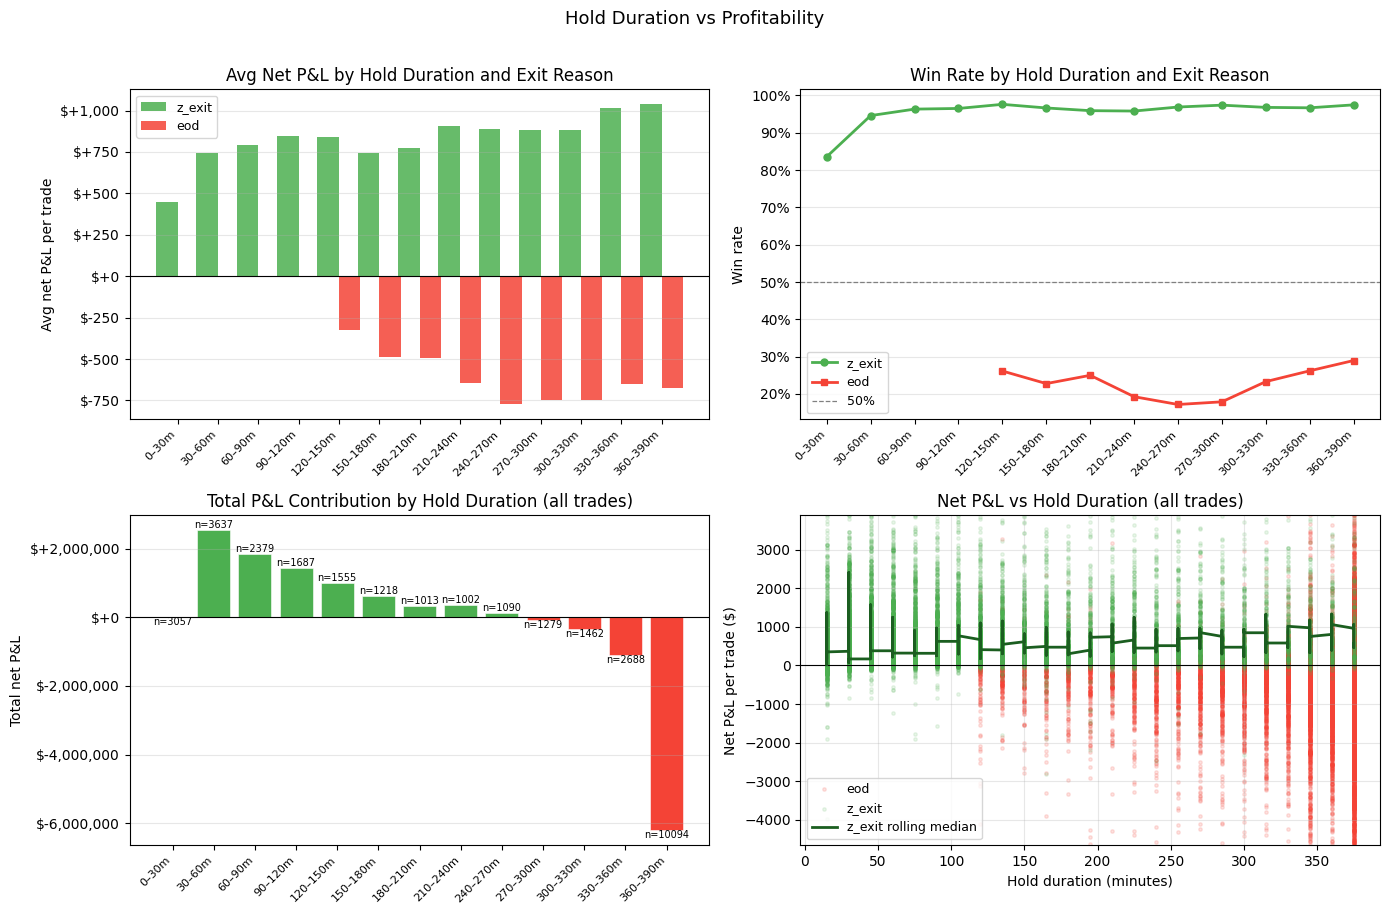

Avg net P&L and win rate by hold duration bucket:
 Hold bucket      n    win%    avg_net    total_net  exit_reason_mix
────────────────────────────────────────────────────────────────────────────────
    0– 30m  3,057   56.8%  $   -0.85  $    -2,591  z_exit=1698 eod=0
   30– 60m  3,637   92.8%  $ +695.20  $+2,528,441  z_exit=3568 eod=0
   60– 90m  2,379   95.9%  $ +773.69  $+1,840,606  z_exit=2368 eod=0
   90–120m  1,687   96.5%  $ +846.67  $+1,428,337  z_exit=1687 eod=0
  120–150m  1,555   85.6%  $ +645.24  $+1,003,346  z_exit=1294 eod=260
  150–180m  1,218   82.2%  $ +496.44  $  +604,666  z_exit=980 eod=237
  180–210m  1,013   71.2%  $ +329.06  $  +333,338  z_exit=660 eod=352
  210–240m  1,002   68.5%  $ +353.81  $  +354,515  z_exit=644 eod=358
  240–270m  1,090   59.4%  $ +108.10  $  +117,833  z_exit=578 eod=512
  270–300m  1,279   51.2%  $  -64.26  $   -82,192  z_exit=536 eod=743
  300–330m  1,462   46.8%  $ -226.01  $  -330,422  z_exit=467 eod=995
  330–360m  2,688   36.5%  $ -409

In [13]:
if len(trades_df) > 0:
    hold_min = (trades_df["exit_time"] - trades_df["entry_time"]).dt.total_minutes()
    trades_h = trades_df.with_columns(hold_min.alias("hold_min"))

    # ── 30-min buckets ────────────────────────────────────────────────────
    trades_h = trades_h.with_columns(
        (pl.col("hold_min") // 30 * 30).cast(pl.Int64).alias("bucket")
    )

    def bucket_stats(df):
        return (
            df.with_columns(pl.when(pl.col("net_pnl") > 0).then(1).otherwise(0).alias("win"))
            .group_by("bucket")
            .agg(
                pl.len().alias("n"),
                pl.col("win").mean().alias("win_rate"),
                pl.col("net_pnl").mean().alias("avg_net_pnl"),
                pl.col("gross_pnl").mean().alias("avg_gross_pnl"),
                pl.col("net_pnl").sum().alias("total_net_pnl"),
            )
            .sort("bucket")
        )

    agg_all   = bucket_stats(trades_h)
    agg_zexit = bucket_stats(trades_h.filter(pl.col("exit_reason") == "z_exit"))
    agg_eod   = bucket_stats(trades_h.filter(pl.col("exit_reason") == "eod"))

    buckets   = agg_all["bucket"].to_list()
    xlabels   = [f"{b}–{b+30}m" for b in buckets]

    # ── Figure ────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    # ── Panel 1: Avg net P&L by bucket, split by exit reason ─────────────
    ax = axes[0, 0]
    w = 8
    bk_z = agg_zexit["bucket"].to_list()
    bk_e = agg_eod["bucket"].to_list()

    ax.bar([b - w for b in bk_z], agg_zexit["avg_net_pnl"].to_list(),
           width=w*2, color="#4CAF50", alpha=0.85, label="z_exit")
    ax.bar([b + w for b in bk_e], agg_eod["avg_net_pnl"].to_list(),
           width=w*2, color="#F44336", alpha=0.85, label="eod")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(buckets)
    ax.set_xticklabels(xlabels, rotation=45, ha="right", fontsize=8)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:+,.0f}"))
    ax.set_ylabel("Avg net P&L per trade")
    ax.set_title("Avg Net P&L by Hold Duration and Exit Reason")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

    # ── Panel 2: Win rate by bucket, split by exit reason ────────────────
    ax = axes[0, 1]
    ax.plot(bk_z, agg_zexit["win_rate"].to_list(),
            marker="o", color="#4CAF50", linewidth=2, markersize=5, label="z_exit")
    ax.plot(bk_e, agg_eod["win_rate"].to_list(),
            marker="s", color="#F44336", linewidth=2, markersize=5, label="eod")
    ax.axhline(0.5, color="grey", linewidth=0.9, linestyle="--", label="50%")
    ax.set_xticks(bk_z)
    ax.set_xticklabels([f"{b}–{b+30}m" for b in bk_z], rotation=45, ha="right", fontsize=8)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.set_ylabel("Win rate")
    ax.set_title("Win Rate by Hold Duration and Exit Reason")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

    # ── Panel 3: Total P&L contribution by bucket ─────────────────────────
    ax = axes[1, 0]
    totals = agg_all["total_net_pnl"].to_list()
    colors = ["#4CAF50" if v >= 0 else "#F44336" for v in totals]
    ax.bar(xlabels, totals, color=colors, edgecolor="white", linewidth=0.4)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:+,.0f}"))
    ax.set_xticklabels(xlabels, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Total net P&L")
    ax.set_title("Total P&L Contribution by Hold Duration (all trades)")
    ax.grid(axis="y", alpha=0.3)

    # Annotate trade counts
    for i, (total, n) in enumerate(zip(totals, agg_all["n"].to_list())):
        ax.text(i, total + (500 if total >= 0 else -500),
                f"n={n}", ha="center", va="bottom" if total >= 0 else "top",
                fontsize=7, color="black")

    # ── Panel 4: Scatter — hold duration vs net P&L (all trades) ─────────
    ax = axes[1, 1]
    hold_arr = trades_h["hold_min"].to_numpy()
    net_arr  = trades_h["net_pnl"].to_numpy()
    reason   = trades_h["exit_reason"].to_list()

    mask_z = [r == "z_exit" for r in reason]
    mask_e = [r == "eod"    for r in reason]

    ax.scatter(hold_arr[[i for i, m in enumerate(mask_e) if m]],
               net_arr[[i for i, m in enumerate(mask_e) if m]],
               alpha=0.15, s=6, color="#F44336", label="eod", rasterized=True)
    ax.scatter(hold_arr[[i for i, m in enumerate(mask_z) if m]],
               net_arr[[i for i, m in enumerate(mask_z) if m]],
               alpha=0.12, s=6, color="#4CAF50", label="z_exit", rasterized=True)

    # Running median for z_exit trades
    import numpy as np
    z_idx    = np.array([i for i, m in enumerate(mask_z) if m])
    z_hold   = hold_arr[z_idx]
    z_net    = net_arr[z_idx]
    sort_idx = np.argsort(z_hold)
    win_med  = 30
    meds_x, meds_y = [], []
    for i in range(win_med // 2, len(sort_idx) - win_med // 2):
        window = z_net[sort_idx[max(0, i - win_med // 2): i + win_med // 2]]
        meds_x.append(z_hold[sort_idx[i]])
        meds_y.append(float(np.median(window)))
    ax.plot(meds_x, meds_y, color="#1B5E20", linewidth=2,
            label="z_exit rolling median", zorder=5)

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Hold duration (minutes)")
    ax.set_ylabel("Net P&L per trade ($)")
    ax.set_title("Net P&L vs Hold Duration (all trades)")
    ax.legend(fontsize=9)
    ax.set_ylim(np.percentile(net_arr, 1), np.percentile(net_arr, 99))
    ax.grid(alpha=0.3)

    plt.suptitle("Hold Duration vs Profitability", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

    # ── Print summary table ───────────────────────────────────────────────
    print("Avg net P&L and win rate by hold duration bucket:")
    print(f"{'Hold bucket':>12}  {'n':>5}  {'win%':>6}  {'avg_net':>9}  {'total_net':>11}  exit_reason_mix")
    print("─" * 80)
    for row in agg_all.iter_rows(named=True):
        b = row["bucket"]
        n_z = int(trades_h.filter((pl.col("bucket") == b) & (pl.col("exit_reason") == "z_exit")).shape[0])
        n_e = int(trades_h.filter((pl.col("bucket") == b) & (pl.col("exit_reason") == "eod")).shape[0])
        mix = f"z_exit={n_z} eod={n_e}"
        print(f"  {b:3d}–{b+30:3d}m  {row['n']:>5,}  {row['win_rate']:>6.1%}  "
              f"${row['avg_net_pnl']:>+8.2f}  ${row['total_net_pnl']:>+10,.0f}  {mix}")

    print()
    corr = float(trades_h.select(pl.corr("hold_min", "net_pnl")).item())
    print(f"Pearson corr(hold_min, net_pnl): {corr:+.4f}")
    print(f"→ Negative correlation: longer holds are associated with lower net P&L.")